
# The Clinical Forecaster (ANOVA & Regression)

## Learning Objectives
By the end of this demo, you will be able to:
1. Clean and preprocess real-world medical data
2. Perform Exploratory Data Analysis (EDA) with visualizations
3. Conduct statistical hypothesis testing using ANOVA
4. Build and evaluate a regression model
5. Deploy the model for real predictions

# The Clinical Forecaster (ANOVA & Regression)


**The Scenario**

You are the Ward Manager at a Federal Medical Center. Bed space is a critical issue. When a patient is admitted with Severe Malaria, you need to know exactly how many days they will occupy a bed based on their admission details.

You have data from 300 past patients.
Your Goal:

    Use ANOVA to figure out which Treatment Protocol gets patients out of the hospital fastest.

    Build an AI Regression model to predict the exact number of days a new patient will stay.

In [407]:
# Import the libraries you will use
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv("./dataset/malaria_ward_dataset.csv")
df.head()

,Patient_ID,Age,Admission_Temp,Parasite_Density,Treatment_Protocol,Recovery_Days
0,MAL000,19,39.926520,97761,Quinine_IV,15.0
1,MAL001,58,38.804007,23779,ACT_plus_Antibiotic,7.5
2,MAL002,43,40.245095,84992,Quinine_IV,15.1
3,MAL003,58,38.836646,99937,ACT_Only,10.0
4,MAL004,62,41.525414,72652,ACT_Only,15.1


Step 1: Data Cleaning & Pre-processing

Real-world data is messy. We have missing values in Admission_Temp and Recovery_Days.

Temperature: We use the Median because it is robust against outliers (unlike the mean).

Drop NAs: We drop rows where the target (Recovery_Days) is missing, as we cannot train a model without the answer.

### Check datatypes of the dataset

In [408]:
df.dtypes

Patient_ID             object
Age                     int64
Admission_Temp        float64
Parasite_Density        int64
Treatment_Protocol     object
Recovery_Days         float64
dtype: object

### Check for duplicates

In [409]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


## Step 1: Data Cleaning & Pre-processing

Let's clean the missing temperatures. Since temperatures shouldn't be guessed with a mean (a mean might hide a fever), we will use the Median.

In [410]:
# Check missing data
print("Missing Data Before Cleaning:\n", df.isnull().sum())

# Impute Temperature with Median
median_temp = df['Admission_Temp'].median()
df['Admission_Temp'] = df['Admission_Temp'].fillna(median_temp)

# Drop rows where Target is missing
df = df.dropna(subset=['Recovery_Days'])

print("\nMissing Data After Cleaning:\n", df.isnull().sum())

Missing Data Before Cleaning:
 Patient_ID             0
Age                    0
Admission_Temp        10
Parasite_Density       0
Treatment_Protocol     0
Recovery_Days         10
dtype: int64

Missing Data After Cleaning:
 Patient_ID            0
Age                   0
Admission_Temp        0
Parasite_Density      0
Treatment_Protocol    0
Recovery_Days         0
dtype: int64


In [411]:
# To view the columns in our dataset
df.columns

Index(['Patient_ID', 'Age', 'Admission_Temp', 'Parasite_Density',
       'Treatment_Protocol', 'Recovery_Days'],
      dtype='object')

In [412]:
df.isnull().sum()

Patient_ID            0
Age                   0
Admission_Temp        0
Parasite_Density      0
Treatment_Protocol    0
Recovery_Days         0
dtype: int64

In [413]:
# df.to_string()
df.head(10)

,Patient_ID,Age,Admission_Temp,Parasite_Density,Treatment_Protocol,Recovery_Days
0,MAL000,19,39.926520,97761,Quinine_IV,15.0
1,MAL001,58,38.804007,23779,ACT_plus_Antibiotic,7.5
2,MAL002,43,40.245095,84992,Quinine_IV,15.1
3,MAL003,58,38.836646,99937,ACT_Only,10.0
4,MAL004,62,41.525414,72652,ACT_Only,15.1
5,MAL005,25,40.399122,90842,ACT_plus_Antibiotic,11.7
6,MAL006,28,39.931462,48266,ACT_plus_Antibiotic,10.4
7,MAL007,25,40.510282,90561,ACT_plus_Antibiotic,13.4
8,MAL008,32,37.395717,47690,ACT_Only,6.7
10,MAL010,42,41.102493,53580,Quinine_IV,16.5


## Step 2: Exploratory Data Analysis (EDA)

We visualize the data to understand distributions and relationships.

Boxplot: To compare recovery times across different treatments.

Scatterplot: To see the relationship between Age/Parasite Density and Recovery Days.

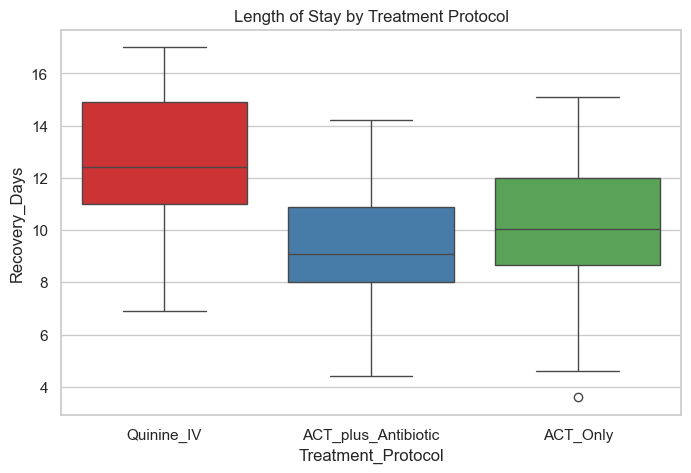

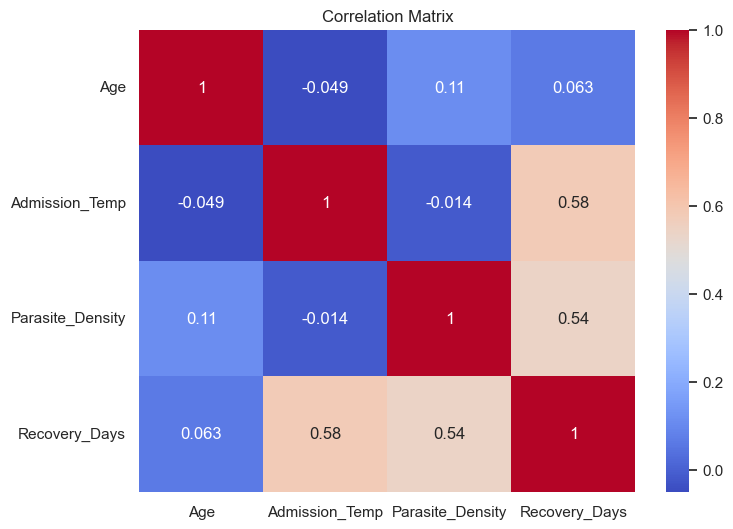

In [414]:
# Set theme
sns.set_theme(style="whitegrid")

# Boxplot for Treatment vs Recovery
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Treatment_Protocol', y='Recovery_Days', palette='Set1')
plt.title('Length of Stay by Treatment Protocol')
plt.show()

# Correlation Matrix
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Perform some data validation

In [415]:
print(df[(df['Age'] < 0 ) | df['Age'] >130]) # invalid age
print(df[ (df['Admission_Temp'] <35 )  | (df['Admission_Temp'] > 43 )]) # invalid temps. I belive 43 is the max?

Empty DataFrame
Columns: [Patient_ID, Age, Admission_Temp, Parasite_Density, Treatment_Protocol, Recovery_Days]
Index: []
Empty DataFrame
Columns: [Patient_ID, Age, Admission_Temp, Parasite_Density, Treatment_Protocol, Recovery_Days]
Index: []


**Interpretation**: Looking at the boxplot, Quinine_IV clearly has the highest median recovery days (the line inside the box is higher). ACT_plus_Antibiotic seems to have the lowest.

## 2.1 Univariate Analysis (Target Variable)

We examine Recovery_Days to check for:

Distribution: Is it normal (bell curve)?

Outliers: Are there extreme values that could skew our model?

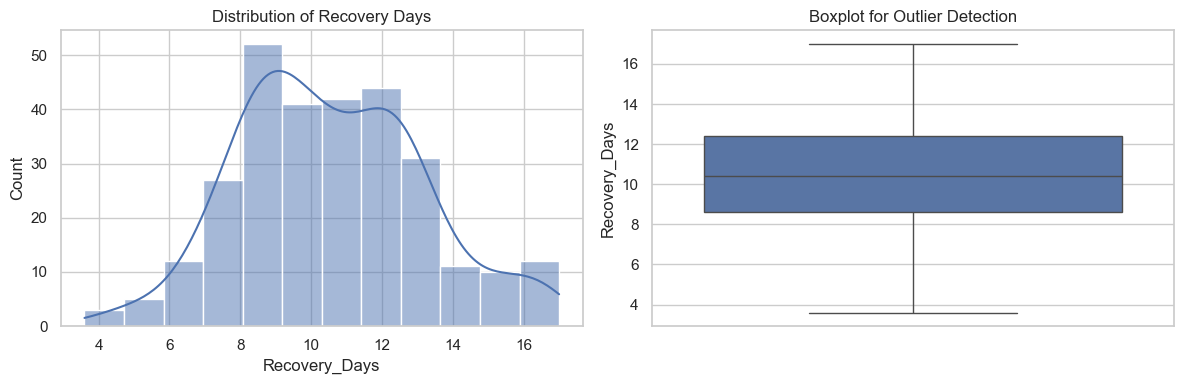

Summary statistics for Recovery days
count    290.000000
mean      10.558276
std        2.615052
min        3.600000
25%        8.600000
50%       10.400000
75%       12.400000
max       17.000000
Name: Recovery_Days, dtype: float64


In [416]:
# Distribution of Recovery Days
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Recovery_Days'], kde=True)
plt.title('Distribution of Recovery Days')

plt.subplot(1, 2, 2)
sns.boxplot(df['Recovery_Days'])
plt.title('Boxplot for Outlier Detection')

plt.tight_layout()
plt.show()

# Summary Stats
print("Summary statistics for Recovery days")
print(df['Recovery_Days'].describe())



## 2.2 Bivariate Analysis (Relationships)

How do our numerical features relate to the target?

Scatter Plots: Help us visualize correlation and linearity.

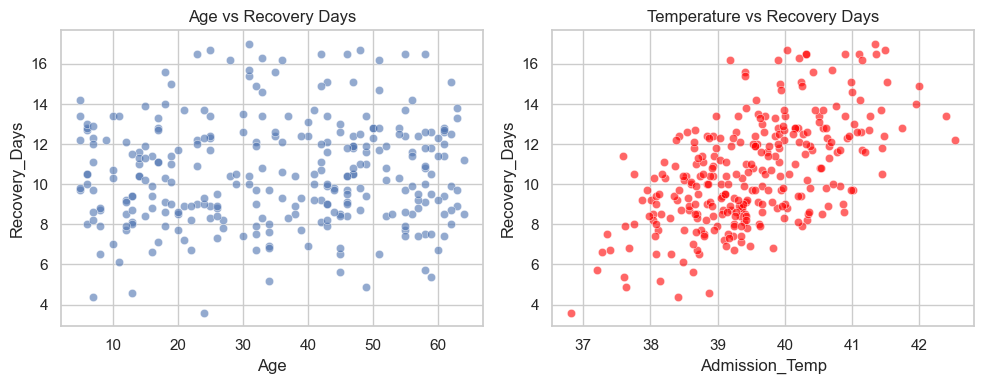

In [417]:
# Age vs Recovery Days
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Age', y='Recovery_Days', data=df, alpha=0.6)
plt.title('Age vs Recovery Days')

# Temperature vs Recovery Days
plt.subplot(1, 2, 2)
sns.scatterplot(x='Admission_Temp', y='Recovery_Days', data=df, alpha=0.6, color='red')
plt.title('Temperature vs Recovery Days')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Parasite density vs Recovery Days')

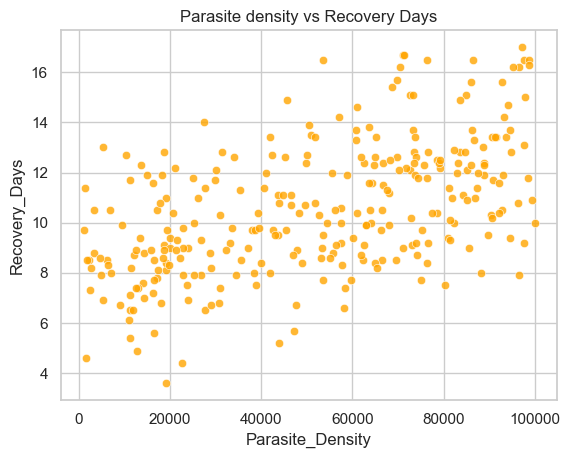

In [418]:
# Temparature vs Recovery Days
sns.scatterplot(x='Parasite_Density', y='Recovery_Days', data=df, alpha=0.8, color='orange')
plt.title("Parasite density vs Recovery Days")

<Axes: xlabel='Treatment_Protocol', ylabel='Recovery_Days'>

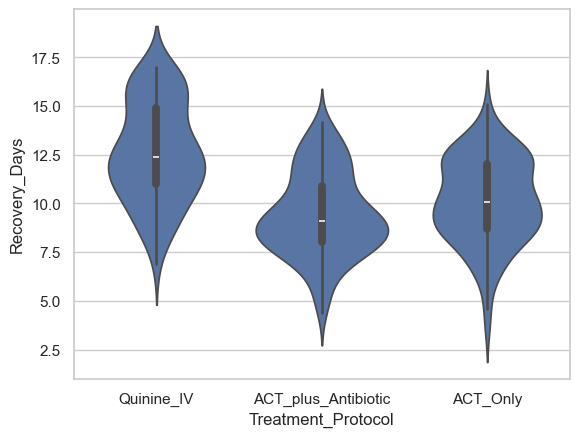

In [419]:
# Violin plot for treatment

sns.violinplot(x='Treatment_Protocol', y='Recovery_Days', data=df)

Text(0.5, 1.0, 'Correltion Matrix')

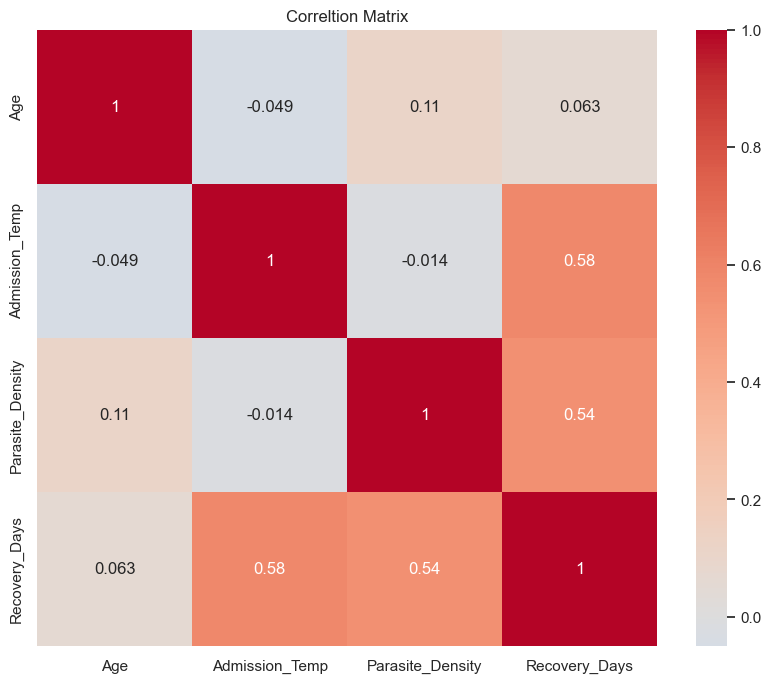

In [420]:
# Correlation matrix

plt.figure(figsize=(10, 8))
corr = df[['Age', 'Admission_Temp', 'Parasite_Density', 'Recovery_Days']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correltion Matrix')

In [421]:
# Summary statistics by treatment
df.groupby('Treatment_Protocol')['Recovery_Days'].describe()

,count,mean,std,min,25%,50%,75%,max
Treatment_Protocol,,,,,,,,
ACT_Only,104.0,10.133654,2.201395,3.6,8.675,10.05,12.0,15.1
ACT_plus_Antibiotic,105.0,9.409524,2.129803,4.4,8.000,9.10,10.9,14.2
Quinine_IV,81.0,12.592593,2.532034,6.9,11.000,12.40,14.9,17.0


Text(0.5, 1.0, 'Median Recovery by Treatment')

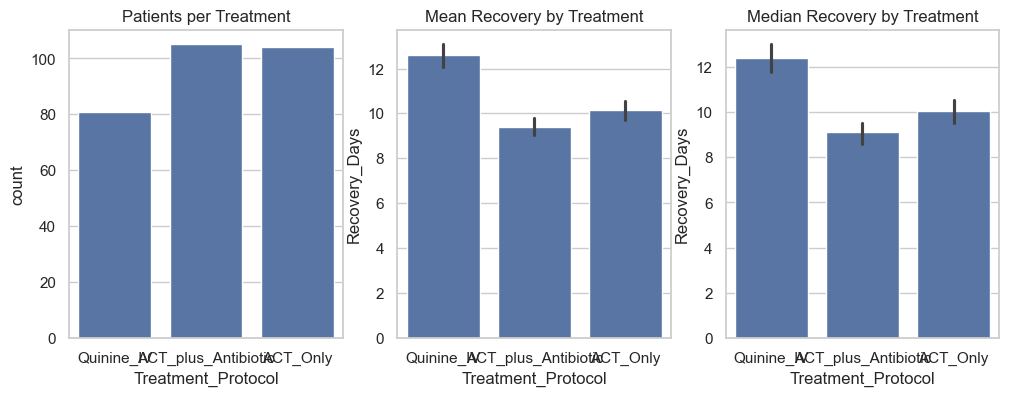

In [422]:
# Count plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.countplot(df, x='Treatment_Protocol')
plt.title('Patients per Treatment')

plt.subplot(1, 3, 2)
sns.barplot(df, x='Treatment_Protocol', y='Recovery_Days', estimator=np.mean)
plt.title('Mean Recovery by Treatment')

plt.subplot(1, 3, 3)
sns.barplot(df, x='Treatment_Protocol', y='Recovery_Days', estimator=np.median)
plt.title('Median Recovery by Treatment')

## Step 3: Biostatistics (The ANOVA Test)

Concept: A T-Test compares TWO groups. But we have THREE drugs. To compare 3 or more groups, we should use ANOVA (Analysis of Variance).

    Null Hypothesis (H0): All 3 drugs result in the exact same average recovery time.

    Rule: If p-value < 0.05, we reject the Null. It means at least one drug is significantly faster/slower than the others.

In [423]:
df['Treatment_Protocol']

0               Quinine_IV
1      ACT_plus_Antibiotic
2               Quinine_IV
3                 ACT_Only
4                 ACT_Only
              ...         
295             Quinine_IV
296               ACT_Only
297             Quinine_IV
298    ACT_plus_Antibiotic
299               ACT_Only
Name: Treatment_Protocol, Length: 290, dtype: object

In [424]:
# 1. Separate the Recovery Days into 3 lists based on the Treatment

act_only = df[df['Treatment_Protocol'] == 'ACT_Only']['Recovery_Days']
quinine = df[df['Treatment_Protocol'] == 'Quinine_IV']['Recovery_Days']
act_anti = df[df['Treatment_Protocol'] == 'ACT_plus_Antibiotic']['Recovery_Days']


# 2. Homogeneity of variance
from scipy.stats import levene
levene_stat, levene_p = stats.levene(act_only, quinine, act_anti)
print(f"Levene's Test P-value: {levene_p:.4f}")



# Check ANOVA assumptions
# 3. Normality test
from scipy.stats import shapiro
print("Normality Test:")
for group in [act_only, quinine, act_anti]:
    stat, p = shapiro(group)
    print(f"P-value: {p:.4f} - {'Normal' if p > 0.05 else 'Not Normal'}")
    
    
# 4. Run the ANOVA test (f_oneway)

f_stat, p_val_anova = stats.f_oneway(act_only, quinine, act_anti)

print("--- ANOVA TEST RESULTS ---")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_val_anova:.6f}")

if p_val_anova < 0.05:
    print("\nClinical Conclusion: P < 0.05. There is a STATISTICALLY SIGNIFICANT difference in recovery times between the 3 treatment protocols.")
else:
    print("\nClinical Conclusion: P > 0.05. The drugs all perform roughly the same.")

Levene's Test P-value: 0.1355
Normality Test:
P-value: 0.1853 - Normal
P-value: 0.0391 - Not Normal
P-value: 0.0664 - Normal
--- ANOVA TEST RESULTS ---
F-Statistic: 47.63
P-Value: 0.000000

Clinical Conclusion: P < 0.05. There is a STATISTICALLY SIGNIFICANT difference in recovery times between the 3 treatment protocols.


In [425]:
# RUN Post-hoc Tukey HSD (if ANOVA is significant)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(df['Recovery_Days'], df['Treatment_Protocol'], alpha=0.05)
print(tukey)

             Multiple Comparison of Means - Tukey HSD, FWER=0.05             
       group1              group2       meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------------
           ACT_Only ACT_plus_Antibiotic  -0.7241 0.0571 -1.4652  0.017  False
           ACT_Only          Quinine_IV   2.4589    0.0  1.6651 3.2528   True
ACT_plus_Antibiotic          Quinine_IV   3.1831    0.0  2.3909 3.9753   True
-----------------------------------------------------------------------------


In [426]:
# Effect size (eta-squared)
ss_between = sum([(len(group) * (group.mean() - df['Recovery_Days'].mean())**2) 
                  for group in [act_only, quinine, act_anti]])
ss_total = ((df['Recovery_Days'] - df['Recovery_Days'].mean())**2).sum()
eta_squared = ss_between / ss_total
print(f"Effect Size (Eta-squared): {eta_squared:.3f}")

Effect Size (Eta-squared): 0.249


## Feature Engineering 

**What is it?**

Feature Engineering is the art of using domain knowledge to create new features from existing data to help the machine learning model perform better. It is often said that "data is fuel, but feature engineering is the engine." 

**Why do we do it?** 

Improve Predictive Power: Raw data often hides patterns. For example, a raw "Age" number might be less useful than an "Age_Group" (e.g., Child, Adult, Senior) if certain age groups recover faster. 

Simplification: It helps the model understand complex relationships without needing complicated algorithms. By creating a "High_Fever" flag (Yes/No), we make it easier for the model to recognize that fever impacts recovery time. 

### **Feature Scaling** 

**What is it?**

Feature scaling is the process of normalizing the range of independent variables (features). For example, "Age" ranges from 0–100, but "Parasite_Density" ranges from 0–100,000. 

**Why do we do it?**

**Fairness:** Many algorithms (like Linear Regression, KNN, and Neural Networks) calculate distances between data points. If one feature has a huge range (Parasite Density) and another has a small range (Age), the model will think Parasite Density is the only thing that matters simply because the numbers are bigger. Scaling puts them on the same playing field (usually between -1 and 1, or 0 and 1). 

**Convergence Speed:** Optimization algorithms (like Gradient Descent) converge faster when features are on similar scales. 


#### **Evaluation Metrics (MAE, R2, RMSE)** 

When we build regression models (predicting numbers), we cannot use "Accuracy" like we do for classification. We use these metrics instead: 
     

**MAE (Mean Absolute Error):**

What it does: It calculates the average absolute difference between the predicted values and the actual values.

Interpretation: "On average, my prediction is wrong by X days."

Why use it: It is very easy to understand and explain to non-technical stakeholders (like doctors).
         
     

**RMSE (Root Mean Squared Error):**

What it does: It squares the errors before averaging them, and then takes the square root.

Interpretation: Similar to MAE, but penalizes large errors more heavily.

Why use it: If a small error is okay, but a huge error is dangerous (e.g., predicting a patient leaves in 2 days but they stay for 20), RMSE highlights this better than MAE.
         
     

**R² (R-Squared / Coefficient of Determination):**

What it does: It represents the proportion of the variance for the dependent variable that's explained by the independent variables. It ranges from 0 to 1 (usually).

**Interpretation:** An R² of 0.82 means the model explains 82% of the variation in recovery days.

Why use it: It tells you "how well" the model fits the data overall, rather than just measuring error.

In [427]:
# Shape shape of Dataset before feature Engineering
print(f"The sahpe of our data set: {df.shape}")
print(f"The size of our dataset: {df.size}")

df

The sahpe of our data set: (290, 6)
The size of our dataset: 1740


,Patient_ID,Age,Admission_Temp,Parasite_Density,Treatment_Protocol,Recovery_Days
0,MAL000,19,39.926520,97761,Quinine_IV,15.0
1,MAL001,58,38.804007,23779,ACT_plus_Antibiotic,7.5
2,MAL002,43,40.245095,84992,Quinine_IV,15.1
3,MAL003,58,38.836646,99937,ACT_Only,10.0
4,MAL004,62,41.525414,72652,ACT_Only,15.1
...,...,...,...,...,...,...
295,MAL295,11,39.302677,73773,Quinine_IV,13.4
296,MAL296,38,39.953123,32337,ACT_Only,8.9
297,MAL297,12,38.648322,70109,Quinine_IV,12.1
298,MAL298,44,40.365442,55146,ACT_plus_Antibiotic,8.6


### Feature Engineering

In [428]:
# 1. Create New Features
df['High_Fever'] = (df['Admission_Temp'] > 39).astype(int)
df['Severe_Density'] = (df['Parasite_Density'] > 50000).astype(int)
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 12, 18, 60, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])

# 2. One-Hot Encoding for Categorical Variables
# Note: We engineer features BEFORE encoding/splitting so the new features are included.
df_encoded = pd.get_dummies(df, columns=['Treatment_Protocol'], drop_first=True)

# Drop ID column as it is not predictive
df_encoded = df_encoded.drop(['Patient_ID'], axis=1)

print("Dataset shape after Engineering & Encoding:", df_encoded.shape)
df_encoded.head()

Dataset shape after Engineering & Encoding: (290, 9)


,Age,Admission_Temp,Parasite_Density,Recovery_Days,High_Fever,Severe_Density,Age_Group,Treatment_Protocol_ACT_plus_Antibiotic,Treatment_Protocol_Quinine_IV
0,19,39.926520,97761,15.0,1,1,Adult,False,True
1,58,38.804007,23779,7.5,0,0,Adult,True,False
2,43,40.245095,84992,15.1,1,1,Adult,False,True
3,58,38.836646,99937,10.0,0,1,Adult,False,False
4,62,41.525414,72652,15.1,1,1,Senior,False,False


## Building a pipline that will contain model and scalar

In [429]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
import joblib

# 1. Define which columns are numeric and which are categorical
# Note: We include the engineered features 'High_Fever' and 'Severe_Density' as numeric
numeric_features = ['Age', 'Admission_Temp', 'Parasite_Density', 'High_Fever', 'Severe_Density']
categorical_features = ['Treatment_Protocol']

# 2. Create transformers
# Numeric: Apply StandardScaler
numeric_transformer = StandardScaler()

# Categorical: Apply OneHotEncoder (handle_unknown='ignore' allows it to work even if new categories appear later)
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

# 3. Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Create the full Pipeline
# Step 1: Preprocess (Scale + Encode)
# Step 2: Model (Linear Regression)
pipeline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 5. Prepare Data for Pipeline
# We don't need to manually scale or encode. We just need X and y.
# Let's re-create X and y from the 'df' that has our new features (High_Fever, etc.)
X = df[['Age', 'Admission_Temp', 'Parasite_Density', 'High_Fever', 'Severe_Density', 'Treatment_Protocol']]
y = df['Recovery_Days']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train the Pipeline
pipeline_model.fit(X_train, y_train)
print("Pipeline Model Trained Successfully.")

# 7. Save the Pipeline (This saves Scaler + Encoder + Model in one file)
joblib.dump(pipeline_model, 'models/clinical_forecaster_pipeline.pkl')
print("Pipeline saved to 'models/clinical_forecaster_pipeline.pkl'")

Pipeline Model Trained Successfully.
Pipeline saved to 'models/clinical_forecaster_pipeline.pkl'


## Deployment (Loading the Pipeline)

we can pass raw data (like Treatment names) directly to the model. The pipeline handles the conversion and scaling internally.

In [430]:
import joblib
import pandas as pd

# 1. Load the Pipeline
loaded_pipeline = joblib.load('models/clinical_forecaster_pipeline.pkl')

# 2. Create a function to predict using the Loaded Pipeline
def predict_with_pipeline(age, temp, density, treatment):
    # We still calculate our engineered features manually before passing them in
    # (Because the pipeline expects them based on how we trained it)
    high_fever = 1 if temp > 39 else 0
    severe_density = 1 if density > 50000 else 0
    
    # Create a dataframe with the RAW inputs
    # The pipeline will handle Scaling and One-Hot Encoding automatically
    input_data = pd.DataFrame({
        'Age': [age],
        'Admission_Temp': [temp],
        'Parasite_Density': [density],
        'High_Fever': [high_fever],
        'Severe_Density': [severe_density],
        'Treatment_Protocol': [treatment] 
    })
    
    # Predict
    prediction = loaded_pipeline.predict(input_data)
    return prediction[0]

# 3. Test the Loaded Model
# Scenario: 10-year-old, High Fever, High Density, ACT_Only
predicted_days = predict_with_pipeline(10, 40.2, 85000, "ACT_Only")

print(f"Predicted Length of Stay: {predicted_days:.1f} days")

Predicted Length of Stay: 12.9 days


## Step 5: Model Building & Evaluation

We will use a Linear Regression model.

Evaluation Metrics Explained

MAE (Mean Absolute Error): The average difference between prediction and reality. (Easiest to interpret).

RMSE (Root Mean Squared Error): Penalizes large errors more than small errors.

R² (R-Squared): How much of the variance in recovery days is explained by the model. It is ranged fron 0 to 1, higher is better.

In [431]:
# We use the trained **Pipeline** to evaluate our model. The pipeline ensures that our test data is 
# scaled and encoded correctly before making predictions.

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Predict using the Pipeline (it handles scaling/encoding internally)
y_pred = pipeline_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Report ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} days")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} days")
print(f"R-Squared Score: {r2:.2f}")
print(f"\nInterpretation: This model can explain {r2*100:.1f}% of the variation in patient recovery time.")



--- Model Performance Report ---
Mean Absolute Error (MAE): 0.84 days
Root Mean Squared Error (RMSE): 1.07 days
R-Squared Score: 0.82

Interpretation: This model can explain 82.3% of the variation in patient recovery time.


## Comparing Multiple Models

We shouldn't just guess which algorithm works best. We will compare:

Linear Regression: The standard baseline.

Ridge & Lasso: Linear models with regularization (to prevent overfitting).

Random Forest: A tree-based model (handles non-linear patterns well).

Gradient Boosting: An advanced ensemble method.

We create a Pipeline for each one to ensure fair comparison.

In [432]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

# 1. Define the Preprocessor (Same as before)
# This ensures every model gets the same scaling and encoding treatment
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# 2. Define the models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1), 
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# 3. Loop through, create pipelines, and evaluate
results = {}

print("Training Models...")
for name, regressor in models.items():
    # Create a pipeline for this specific model
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    pred = pipe.predict(X_test)
    
    # Store results
    results[name] = {
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    }

# 4. Display Comparison
results_df = pd.DataFrame(results).T
print("\n--- Model Comparison Results ---")
print(results_df.sort_values('R2', ascending=False))

Training Models...

--- Model Comparison Results ---
                        MAE      RMSE        R2
Linear Regression  0.840909  1.070137  0.823050
Ridge              0.841953  1.071137  0.822719
Lasso              0.876747  1.101724  0.812450
Random Forest      0.949362  1.190267  0.781093
Gradient Boosting  1.003821  1.243139  0.761213


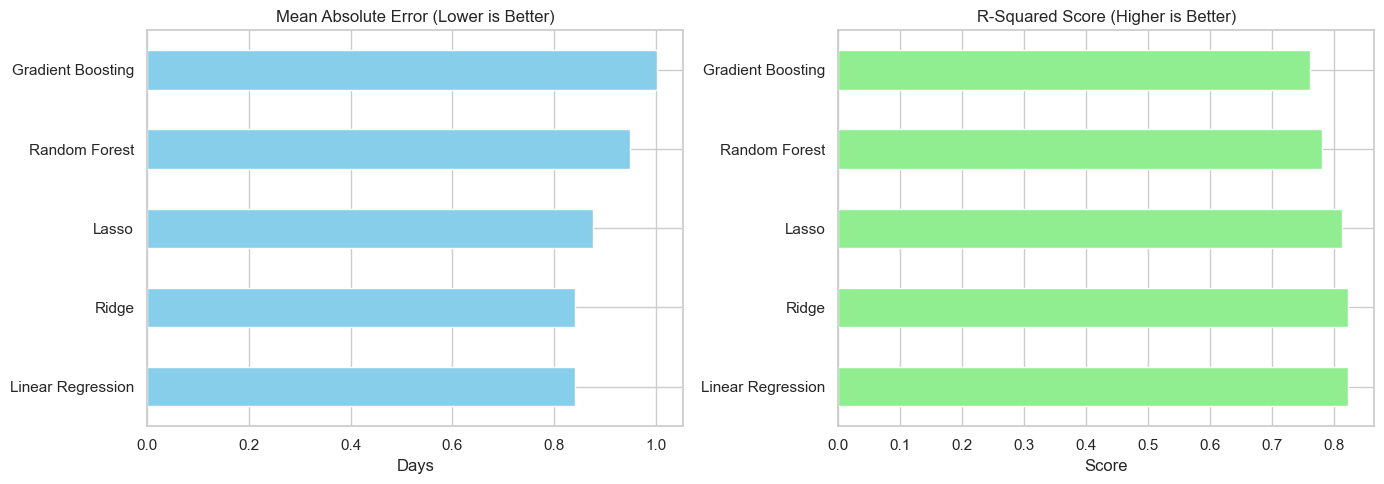

In [433]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MAE (Lower is better)
results_df['MAE'].sort_values().plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Mean Absolute Error (Lower is Better)')
axes[0].set_xlabel('Days')

# Plot 2: R2 Score (Higher is better)
results_df['R2'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='lightgreen')
axes[1].set_title('R-Squared Score (Higher is Better)')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()

## Selecting the best model for the pipeline

In this case, it is the Linear regression

In [434]:
# In case, we want to use another model with the pipline that handles the preprosessing. For instance,
# RandomForestRegressor or any other model you prefer, inside our pipeline to ensure all data 
# preprocessing is handled consistently. We can follow this pattern

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. Initialize the Pipeline with your chosen model
# We reuse the 'preprocessor' defined earlier which contains the Scaler and Encoder
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 2. Train the entire Pipeline
# We pass the RAW X_train. The pipeline scales 'Age' and 'Temp' and encodes 'Treatment' for us!
lr_pipeline.fit(X_train, y_train)

# 3. Predict using the Pipeline
# Again, we pass the RAW X_test. The pipeline handles the conversion.
y_pred = lr_pipeline.predict(X_test)

# 4. Evaluate the performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Final Model Performance Report ---")
print(f"Model Used: {lr_pipeline.named_steps['regressor'].__class__.__name__}")
print(f"Mean Absolute Error (MAE): {mae:.2f} days")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} days")
print(f"R-Squared Score: {r2:.2f}")
print(f"\nInterpretation: This model can explain {r2*100:.1f}% of the variation in patient recovery time.")

# 5. Save this final pipeline
joblib.dump(lr_pipeline, 'models/clinical_forecaster_best.pkl')
print("\nFinal best model saved to 'models/clinical_forecaster_best.pkl'")

--- Final Model Performance Report ---
Model Used: LinearRegression
Mean Absolute Error (MAE): 0.84 days
Root Mean Squared Error (RMSE): 1.07 days
R-Squared Score: 0.82

Interpretation: This model can explain 82.3% of the variation in patient recovery time.

Final best model saved to 'models/clinical_forecaster_best.pkl'


### Step 5.1: Cross-Validation (Model Stability Check)

**Why?** To ensure our model is not just lucky with the current train/test split.

We test it 5 different times on 5 different subsets of the data.

In [435]:


from sklearn.model_selection import cross_val_score

# 1. We use the last pipline (which includes scaling + encoding)
# 2. We use the FULL X and y (CV handles the splitting for us)
# 3. We check for R2 (Goodness of fit) and MAE (Average error)

# CV for R-Squared
cv_r2 = cross_val_score(lr_pipeline, X, y, cv=5, scoring='r2')

# CV for MAE (Scikit-learn uses 'negative' MAE because it prefers 'higher is better')
cv_mae = cross_val_score(lr_pipeline, X, y, cv=5, scoring='neg_mean_absolute_error')
actual_mae_scores = -cv_mae # Convert back to positive numbers

print("--- 5-FOLD CROSS-VALIDATION RESULTS ---")
print(f"R² Scores for each fold: {cv_r2}")
print(f"Average R²: {cv_r2.mean():.3f} (+/- {cv_r2.std():.3f} stability)")
print(f"\nAverage MAE: {actual_mae_scores.mean():.2f} Days")



--- 5-FOLD CROSS-VALIDATION RESULTS ---
R² Scores for each fold: [0.85855537 0.88549594 0.889415   0.79569484 0.86145594]
Average R²: 0.858 (+/- 0.034 stability)

Average MAE: 0.76 Days


### Interpretation:
A low standard deviation (the +/- part) means our model is STABLE.

It will perform similarly no matter which patients it sees.

## Step 5.2: Advanced Model Evaluation

--- Advanced Performance Report ---
Root Mean Squared Error (RMSE): 1.07 Days
Mean Absolute Percentage Error (MAPE): 8.0%
Explained Variance Score: 0.823


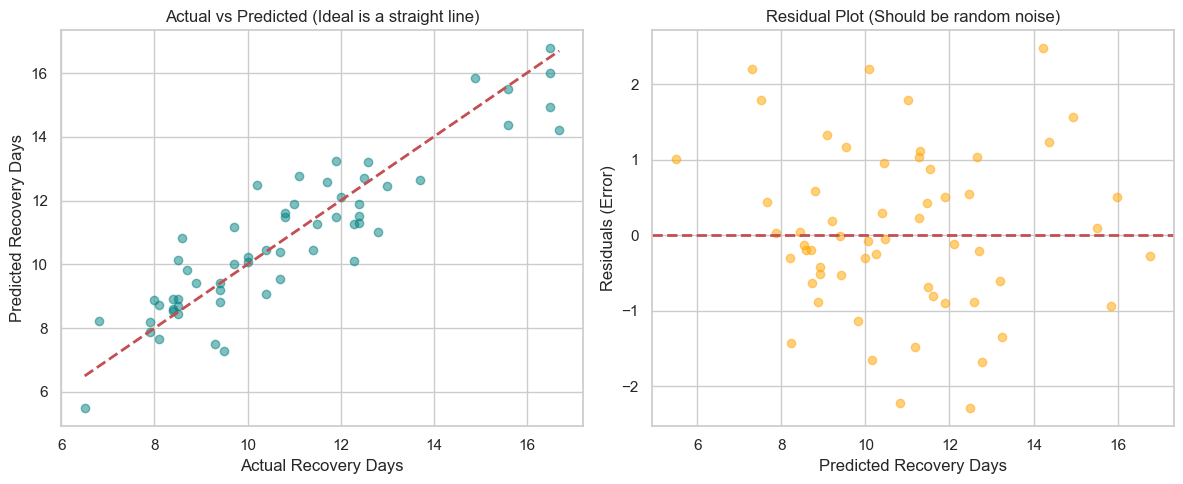

--- Model (AI) BED MANAGEMENT FORECAST ---
Predicted Length of Stay: 12.9 Days
Planning Action: Do not schedule this bed for a new patient for at least 12 days.


In [436]:


#To get a deeper understanding of our model's performance, we look at additional metrics and 
# visualize the errors (residuals).

from sklearn.metrics import mean_squared_error, explained_variance_score

# Additional metrics
# Note: y_test and y_pred are from our best model (lr_pipeline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"--- Advanced Performance Report ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Days")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.1f}%")
print(f"Explained Variance Score: {explained_variance_score(y_test, y_pred):.3f}")

# Residual analysis visualizations
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Recovery Days')
plt.ylabel('Predicted Recovery Days')
plt.title('Actual vs Predicted (Ideal is a straight line)')

# Plot 2: Residual Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5, color='orange')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Recovery Days')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot (Should be random noise)')

plt.tight_layout()
plt.show()


## Step 6: Deploying on a New Patient

# Scenario: A 10-year-old boy is admitted to the ward.
# - Admission Temp: 40.2°C (Very high)
# - Parasite Density: 85,000 /uL
# - Treatment Prescribed: ACT_Only

# How many days will he tie up this bed? We use our `predict_with_pipeline` function
# which uses the saved model.

# 1. Test the Loaded Model with the new patient
# We use the function we created earlier
predicted_days = predict_with_pipeline(10, 40.2, 85000, "ACT_Only")

print("--- Model (AI) BED MANAGEMENT FORECAST ---")
print(f"Predicted Length of Stay: {predicted_days:.1f} Days")
print(f"Planning Action: Do not schedule this bed for a new patient for at least {int(predicted_days)} days.")